In [6]:
import sys
sys.path.insert(0, "src")

import torch
import torch.nn.functional as F
import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

from fsq_ae import load_fsq_ae
from fsq_ae.dataset import EmotionEmbedDataset

In [7]:
ckpt_path = "../../data/checkpoints/fsq_ae/best.pt"

model, cfg, norm = load_fsq_ae(ckpt_path, device="cuda")
model.eval()

dataset = EmotionEmbedDataset("/home/cap/data/processed/emotion2vec_dataset.pt")

print(f"모델 파라미터: {sum(p.numel() for p in model.parameters()):,}")
print(f"코드북 크기: {model.quantizer.codebook_size:,}")
print(f"데이터셋: {len(dataset):,}개")
print(f"감정 종류: {sorted(set(dataset.emotions))}")

[Dataset] N=48,148, D=1024, 화자 1,271명
모델 파라미터: 1,320,456
코드북 크기: 390,625
데이터셋: 48,148개
감정 종류: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'other', 'sad', 'surprised']


In [14]:
# 무작위 5개 발화 reconstruction
import random
random.seed(42)
sample_idx = random.sample(range(len(dataset)), 5)

print("Sanity Check — Reconstruction 검증")

for idx in sample_idx:
    x = dataset[idx].unsqueeze(0).cuda()
    
    with torch.no_grad():
        x_recon, z, z_q = model(x)
    
    cos = F.cosine_similarity(x, x_recon, dim=-1).item()
    mse = ((x - x_recon) ** 2).mean().item()
    emotion = dataset.emotions[idx]
    
    z_q_arr = z_q.squeeze().cpu().numpy()
    
    print(f"\nIdx {idx} (감정: {emotion})")
    print(f"  MSE: {mse:.5f}, cos: {cos:.4f}")
    print(f"  z_q: {z_q_arr.round(3)}")
    print(f"  고유 값: {sorted(set(z_q_arr.round(3).tolist()))}")

Sanity Check — Reconstruction 검증

Idx 41905 (감정: neutral)
  MSE: 0.02563, cos: 0.9756
  z_q: [ 0.5  0.5  1.   0.5  0.5 -1.   0.5 -0.5]
  고유 값: [-1.0, -0.5, 0.5, 1.0]

Idx 7296 (감정: disgusted)
  MSE: 0.02499, cos: 0.9902
  z_q: [ 0.   0.5 -1.  -1.   0.5  1.   0.  -1. ]
  고유 값: [-1.0, 0.0, 0.5, 1.0]

Idx 1639 (감정: neutral)
  MSE: 0.01244, cos: 0.9843
  z_q: [ 0.5 -1.   1.   0.5 -1.  -1.   0.5  0. ]
  고유 값: [-1.0, 0.0, 0.5, 1.0]

Idx 18024 (감정: fearful)
  MSE: 0.02278, cos: 0.9920
  z_q: [ 1.   1.  -1.   0.  -0.5  1.   1.   0.5]
  고유 값: [-1.0, -0.5, 0.0, 0.5, 1.0]

Idx 16049 (감정: surprised)
  MSE: 0.02416, cos: 0.9955
  z_q: [-0.5 -1.  -1.  -1.   1.  -0.5 -0.5  1. ]
  고유 값: [-1.0, -0.5, 1.0]


전체 z_q shape: (48148, 8)


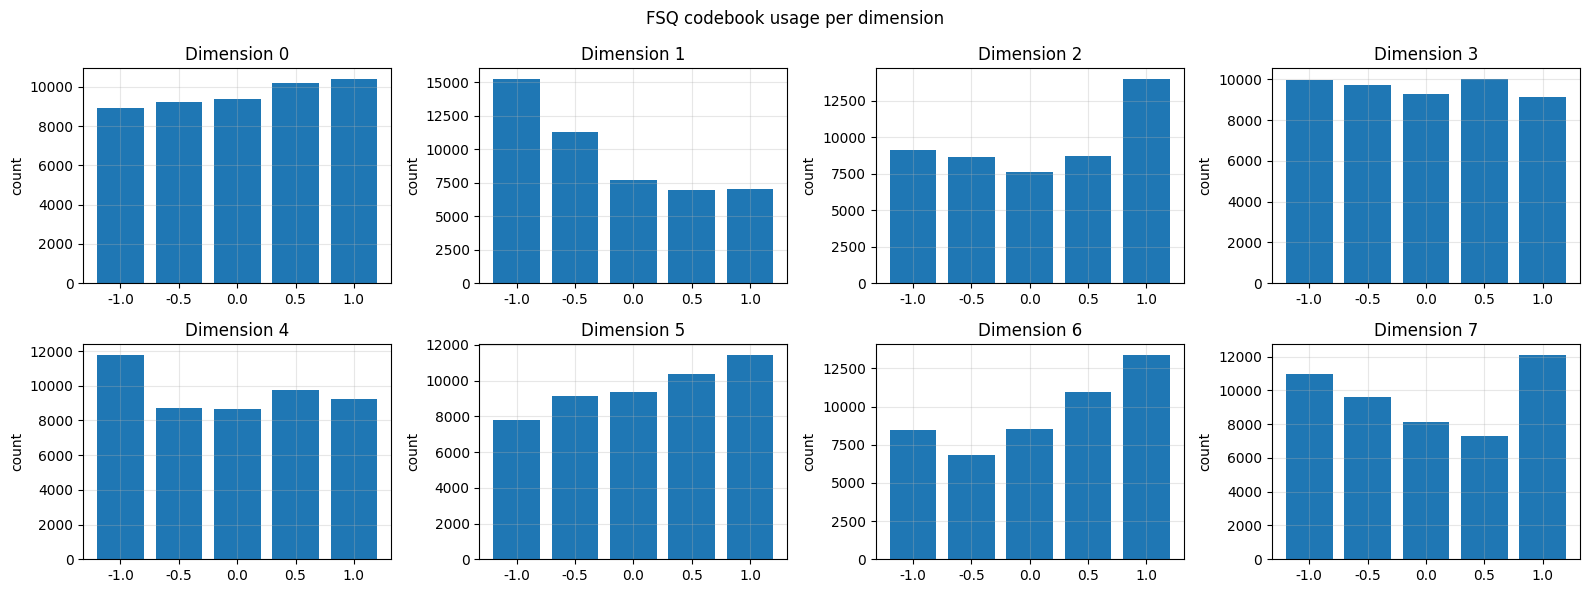

In [9]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from collections import defaultdict, Counter
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update(plt.rcParamsDefault)

# 차원별 코드 사용 패턴
all_z_q = []
loader = DataLoader(dataset, batch_size=512, shuffle=False)
with torch.no_grad():
    for x in loader:
        x = x.cuda()
        z_q = model.quantizer(model.encoder(x))
        all_z_q.append(z_q.cpu().numpy())

all_z_q = np.concatenate(all_z_q)
print(f"전체 z_q shape: {all_z_q.shape}")

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for d in range(8):
    ax = axes[d // 4, d % 4]
    values, counts = np.unique(all_z_q[:, d].round(3), return_counts=True)
    ax.bar([str(v) for v in values], counts)
    ax.set_title(f"Dimension {d}")
    ax.set_ylabel("count")
    ax.grid(alpha=0.3)

plt.suptitle("FSQ codebook usage per dimension")
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=512, shuffle=False)
all_z_q = []

with torch.no_grad():
    for x in loader:
        x = x.cuda()
        z_q = model.quantizer(model.encoder(x))
        all_z_q.append(z_q.cpu().numpy())

all_z_q = np.concatenate(all_z_q)
print(f"전체 z_q shape: {all_z_q.shape}")    # (48148, 8)

print("\n각 차원의 5단계 사용 비율:")
print(f"{'dim':<5s} {'-1.0':>10s} {'-0.5':>10s} {'0.0':>10s} {'0.5':>10s} {'1.0':>10s}")
print("-" * 60)
for d in range(8):
    values = all_z_q[:, d].round(3)
    counts = {}
    for v in [-1.0, -0.5, 0.0, 0.5, 1.0]:
        counts[v] = (values == v).sum()
    total = sum(counts.values())
    
    print(f"{d:<5d}", end="")
    for v in [-1.0, -0.5, 0.0, 0.5, 1.0]:
        pct = counts[v] / total * 100
        print(f" {pct:>9.2f}%", end="")
    print()

전체 z_q shape: (48148, 8)

각 차원의 5단계 사용 비율:
dim         -1.0       -0.5        0.0        0.5        1.0
------------------------------------------------------------
0         18.51%     19.19%     19.50%     21.16%     21.63%
1         31.70%     23.37%     15.95%     14.40%     14.59%
2         18.98%     17.99%     15.82%     18.08%     29.12%
3         20.74%     20.17%     19.25%     20.84%     18.99%
4         24.50%     18.10%     18.04%     20.21%     19.15%
5         16.16%     18.99%     19.44%     21.60%     23.81%
6         17.53%     14.22%     17.70%     22.70%     27.85%
7         22.79%     19.97%     16.89%     15.17%     25.17%


In [13]:
from collections import defaultdict
from torch.utils.data import DataLoader
import numpy as np

loader = DataLoader(dataset, batch_size=512, shuffle=False)

emo_mse = defaultdict(list)
emo_cos = defaultdict(list)

print("감정별 분석")
with torch.no_grad():
    idx = 0
    for x_batch in loader:
        x_batch = x_batch.cuda()
        x_recon, _, _ = model(x_batch)
        
        mse_per = ((x_batch - x_recon) ** 2).mean(dim=-1)
        cos_per = F.cosine_similarity(x_batch, x_recon, dim=-1)
        
        for i in range(x_batch.size(0)):
            emo = dataset.emotions[idx]
            emo_mse[emo].append(mse_per[i].item())
            emo_cos[emo].append(cos_per[i].item())
            idx += 1

print("\n" + "=" * 60)
print(f"{'emotion':<12s} {'count':>8s} {'avg MSE':>12s} {'avg cos':>10s} {'std cos':>10s}")
print("=" * 60)
for emo in sorted(emo_mse.keys()):
    mse_list = emo_mse[emo]
    cos_list = emo_cos[emo]
    print(f"{emo:<12s} {len(mse_list):>8d} "
          f"{np.mean(mse_list):>12.5f} "
          f"{np.mean(cos_list):>10.4f} "
          f"{np.std(cos_list):>10.4f}")

감정별 분석

emotion         count      avg MSE    avg cos    std cos
angry            7000      0.02389     0.9852     0.0110
disgusted        7000      0.02284     0.9824     0.0135
fearful          2294      0.02847     0.9837     0.0125
happy            7000      0.02601     0.9829     0.0114
neutral          7000      0.02679     0.9818     0.0116
other            3854      0.02894     0.9908     0.0072
sad              7000      0.02375     0.9818     0.0121
surprised        7000      0.02511     0.9893     0.0092


In [15]:
from collections import Counter

# train/val 분할 다시 확인
train_set, val_set = dataset.speaker_split(0.1, 66)

# val_set의 emotion 분포
val_emotions = [dataset.emotions[i] for i in val_set.indices]
val_speakers = [dataset.speakers[i] for i in val_set.indices]

print(f"val 발화: {len(val_emotions):,}")
print(f"val 화자: {len(set(val_speakers))}")
print(f"\nval 감정 분포:")
for emo, count in Counter(val_emotions).most_common():
    pct = count / len(val_emotions) * 100
    print(f"  {emo:<12s}: {count:>5d} ({pct:.1f}%)")

# train도 같이
train_emotions = [dataset.emotions[i] for i in train_set.indices]
print(f"\ntrain 발화: {len(train_emotions):,}")
print(f"train 감정 분포:")
for emo, count in Counter(train_emotions).most_common():
    pct = count / len(train_emotions) * 100
    print(f"  {emo:<12s}: {count:>5d} ({pct:.1f}%)")

[Split] 화자 train 1144 / val 127 | 샘플 train 43,687 / val 4,461
val 발화: 4,461
val 화자: 127

val 감정 분포:
  sad         :   678 (15.2%)
  surprised   :   677 (15.2%)
  neutral     :   677 (15.2%)
  disgusted   :   672 (15.1%)
  happy       :   622 (13.9%)
  angry       :   604 (13.5%)
  other       :   340 (7.6%)
  fearful     :   191 (4.3%)

train 발화: 43,687
train 감정 분포:
  angry       :  6396 (14.6%)
  happy       :  6378 (14.6%)
  disgusted   :  6328 (14.5%)
  neutral     :  6323 (14.5%)
  surprised   :  6323 (14.5%)
  sad         :  6322 (14.5%)
  other       :  3514 (8.0%)
  fearful     :  2103 (4.8%)
